# Анализ лояльности пользователей Яндекс Афиши

- Автор: Туркова Екатерина
- Дата: 01.02.2026

## 0.1 Цели и задачи проекта

1. Подключиться к базе данных и выгрузить нужную информацию;
2. Провести предобработку данных;
3. Провести исследовательский анализ данных и выяснить, какие пользователи с большей вероятностью возвращаются на платформу;
4. На основании основных выводов исследовательского анализа дать рекомендации команде маркетинга для увеличения доли возвращающихся пользователей.

## 0.2 Описание данных

В проекте используются данные SQL-запроса, преобразованные в датафрейм data, который содержит следующие столбцы:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (осталвены только 2 типа устройств: mobile — мобильные устройства, desktop — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные created_dt_msk );
- `order_ts` — дата и время создания заказа (используйте данные created_ts_msk );
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее. Исключены фильмы);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

## 0.3 Содержание проекта:

### <b> 1. [Загрузка данных и проверка корректности выгрузки](#1) </b>

На этом этапе проводится инициализация основных рабочих библиотек, загрузка информации из базы данных, обзор первых нескольких строк исходных данных и получение информации о полноте предоставленной информации. Проводятся простые процедуры преобработки: оценка корректности выгрузки, приведение данных к нужным типам.

Список задач, выполненных в этой части:

- <b>[Задача 1.1](#1.1)</b> — выгрузка в датафрейм pandas необходимых данных. Инициализация подключения к базе данных `data-analyst-afisha`. 
- <b>[Задача 1.2](#1.2)</b> — изучение общей информации о выгруженных данных. Оценка корректности и объёма выгруженных данных, приведение данных к нужным типам.

### <b> 2. [Предобработка данных](#2) </b>

Выполнение стандартных процедур предобработки: приведение данных к единым единицам измерения, проверка на пропуски, проверка корректности написания номинальных данных, фильтрация выбросов.

Список задач, выполненных в этой части:

- <b>[Задача 2.1](#2.1)</b> — приведение выручки к единой валюте — российскому рублю.
- <b>[Задача 2.2](#2.2)</b> — проверка на пропуски, проверка правильности написания номинальных данных, исследование распределения выручки с заказов и количества билетов в заказе, фильтрация выбросов в данных.

### <b> 3. [Создание профиля пользователя](#3) </b>

Группировка данных по пользователям. Фильтрация аномальных значений, которые не соответствуют нормальному поведению пользователей и не подходят для анализа.

Список задач, выполненных в этой части:

- <b>[Задача 3.1](#3.1)</b> — построение профиля пользователя.
- <b>[Задача 3.2](#3.2)</b> — оценка репрезентативности данных по пользователям. Исследование распределения общего числа заказов, среднего числа билетов в заказе, среднего количества дней между покупками. Фильтрация выбросов и нерепрезентативных/аномальных данных. 

### <b> 4. [Исследовательский анализ данных](#4) </b>

Список задач, выполненных в этой части:

<b>Блок 4.1:</b> исследование признаков первого заказа и их связи с возвращением на платформу.
- <b>[Задача 4.1.1](#4.1.1)</b> — исследование распределения пользователей по разным признакам.
- <b>[Задача 4.1.2](#4.1.2)</b> — оценка доли возвратов пользователей в сегментации по различным признакам.
- <b>[Задача 4.1.3](#4.1.3)</b> — проверка продуктовых гипотез.

<b>Блок 4.2:</b> исследование поведения пользователей через показатели выручки и состава заказа.
- <b>[Задача 4.2.1](#4.2.1)</b> — исследование связи между средней выручкой сервиса с заказа и повторными заказами.
- <b>[Задача 4.2.2](#4.2.2)</b> — сравнение распределения по средней выручке с заказов в двух группах пользователей.
- <b>[Задача 4.2.3](#4.2.3)</b> — анализ влияния среднего количества билетов в заказе на вероятность повторной покупки.

<b>Блок 4.3:</b> исследование временных характеристик первого заказа и их влияния на повторные покупки.
- <b>[Задача 4.3.1](#4.3.1)</b> — анализ влияния дня недели первой покупки на вероятность возвращения пользователя. 
- <b>[Задача 4.3.2](#4.3.2)</b> — анализ влияния среднего интервала между покупками на удержание клиентов.

<b>Блок 4.4:</b> корреляционный анализ количества покупок и признаков пользователя.
- <b>[Задача 4.4.1](#4.4.1)</b> — корреляционный анализ.


### <b> 5. [Общие выводы и рекомендации](#5) </b>

Краткая информация о данных, с которыми была проведена работа, основные результаты анализа и рекомендации.

## 0.4 Системные требования

В проекте используются следующие библиотеки: 
- sqlalchemy (2.0.46)
- psycopg2 (2.9.11)
- pandas (2.3.3)
- phik (0.12.5)
- seaborn (0.13.2)
- numpy (2.3.5)
- matplotlib (3.10.8)
- python-dotenv(1.2.1) для работы с файлами-секретами в версии проекта на GitHub
- Модуль datetime из datetime 

Я, к сожалению, не знаю, какие версии библиотек устновлены во встроенной системе для работы на платформе Практикума, поэтому привожу список версий используемых мною библиотек. Установка библиотек совместимых версий гарантирует работоспособность кода моего проекта!

Установить библиотеки можно командой !pip install:
- !pip install sqlalchemy 
- !pip install psycopg2 или !pip install psycopg2-binary

Если библиотеки установлены, но текущее окружение по какой-то причине не видит их или не может получить к ним доступ, можно воспользоваться установкой библиотек прямо в окружение:

`import sys`

`!"{sys.executable}" -m pip install -U sqlalchemy`

Проверить версию библиотек в текущем окружении можно командой show:

`import sys`

`!"{sys.executable}" -m pip show sqlalchemy`


---
<a id='1'></a>
## 1. Загрузка данных и проверка корректности выгрузки
<a id='1.1'></a>
<b> Задача 1.1: </b> Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. 

Выгрузка данных осуществляется из базы данных `data-analyst-afisha` через подключение к ней.

In [1]:
# Импорт необходимых для проекта библиотек

from sqlalchemy import create_engine
import psycopg2
import pandas as pd
import phik
import seaborn as sns
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

from dotenv import load_dotenv # Это две библиботеки для работы с секретами
import os  
load_dotenv(dotenv_path='D:\projects\github\final_project\.env')

# Настрока конфигурации подключения к базе данных

db_config = {'user': os.getenv('DB_USER'), # имя пользователя
             'pwd': os.getenv('DB_PWD'), # пароль
             'host': os.getenv('DB_HOST'),
             'port': os.getenv('DB_PORT'), # порт подключения
             'db': os.getenv('DB_DB'), # название базы данных
             }

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

# SQL-запрос, которвый будет использован для выгрузки данных

query = '''
SELECT 
  p.user_id,
  p.device_type_canonical,
  p.order_id,
  p.created_dt_msk AS order_dt,
  p.created_ts_msk AS order_ts,
  p.currency_code,
  p.revenue,
  p.tickets_count,
  (p.created_dt_msk::date
    - LAG(p.created_dt_msk::date) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)
  ) AS days_since_prev,
  p.event_id,
  e.event_name_code AS event_name,
  p.service_name,
  e.event_type_main,
  r.region_name,
  c.city_name
FROM afisha.purchases as p
JOIN afisha.events as e USING(event_id)
JOIN afisha.city as c using(city_id)
JOIN afisha.regions as r using(region_id)
WHERE p.device_type_canonical IN ('mobile', 'desktop') AND e.event_type_main IS DISTINCT FROM 'фильм'
ORDER BY p.user_id ASC
'''

In [2]:
# Инициализация подключения

engine = create_engine(connection_string)

In [3]:
# Выгрузка данных в датафрейм data

data = pd.read_sql_query(query, con=engine)

<a id='1.2'></a>
<b> Задача 1.2: </b> Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.
Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.
Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

In [4]:
# Знакомство с данными через info()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

In [5]:
# Знакомство с данными через describe() 

data.describe()

,order_id,order_dt,order_ts,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611,290611,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,2024-09-01 22:36:38.741272576,2024-09-02 13:31:19.397730816,625.584360,2.754311,3.222381,438019.834992
min,1.000000e+00,2024-06-01 00:00:00,2024-06-01 00:00:42,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,2024-07-30 00:00:00,2024-07-30 11:53:37.500000,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,2024-09-12 00:00:00,2024-09-12 14:02:10,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,2024-10-09 00:00:00,2024-10-09 15:57:55.500000,810.130000,4.000000,1.000000,546287.000000
max,8.653108e+06,2024-10-31 00:00:00,2024-10-31 23:59:54,81174.540000,57.000000,148.000000,592325.000000
std,2.497551e+06,NaN,NaN,1227.693064,1.170620,11.350509,147423.078841


In [6]:
# Выведем 3 первые строки для знакомства с данными

data.head(3)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск


### Промежуточный вывод

- Датафрейм `data` содержит 15 столбцов и 290611 строк. Большинство столбцов имеют тип данных `object`, встречаются также типы `datetime64`, `float64`, `int64`.
- В датафрейме практически отсутствуют пропуски. Ни оден столбец кроме `days_since_prev` не содержит пропусков. Пропуски в этом столбце появились ещё на этапе его создания, так как если покупка у пользователя была первой за рассматриваемый период, то считать время с предыдущей покупки нет смысла (так как её нет). В этом столбце с пропусками ничего делать не нужно.
- Данные охватывают промежуток с 1 июня по 31 октября 2024 года. Это объясняет, почему в столбце `days_since_prev` не встречаются значения более 150 дней.
- В рамках исследовательского анализа данных можно понизить разрядность столбца `tickets_count`, так как диапазон 0...57 "поместится" в int8.
- Возможно, что точность времени заказа до наносекунд излишняя, но мне кажется, что это разрешение выставлено не случайно и такая точность может потребоваться для составления цепочек транзакций. Здесь я ничего не меняла.
- В столбце с выручкой встречаются странные отрицательные значения. Если данные не понадобятся для оценки доли ошибочно заполненных строк, то строчки с отрицательной выручкой будут удалены на этапе исправления ошибок и поиска дубликатов.

In [7]:
# Приведём столбец tickets_count к меньшей разрядности

data['tickets_count'] = data['tickets_count'].astype('int8')

# Посмотрим, что поменялось в информации о датафрейме

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

---
<a id='2'></a>
## 2. Предобработка данных
<a id='2.1'></a>
<b> Задача 2.1. </b> Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для перевода одной валюты из другой потребуется информация об изменении курса валюты за рассматриваемый период. Код адаптирован как для загрузки из локального источника, так и для загрузки с сервера Практикума.

In [8]:
try: 
    csv_currency = pd.read_csv('final_tickets_tenge_df.csv')
    print('Загрузка выполнена успешно. Используются локальные файлы')
except FileNotFoundError: 
    csv_currency = pd.read_csv('https://code.s3.yandex.net//datasets/final_tickets_tenge_df.csv')
    print('Загрузка выполнена успешно. Используются файлы Практикума')

Загрузка выполнена успешно. Используются локальные файлы


In [9]:
csv_currency.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [10]:
# Преобразуем в датафрейме csv_currency столбец data из типа object к типу datetime, чтобы потом можно было выполнить соединение по столбцу

csv_currency['data'] = pd.to_datetime(csv_currency['data'], format = '%Y-%m-%d')

# Создадим промежуточный датафрейм data_rub для преобразования цен без необходимости задействования всего исходного датафрейма data
data_rub = pd.DataFrame()
data_rub[['data', 'order_id', 'revenue', 'currency_code']] = data[['order_dt', 'order_id', 'revenue', 'currency_code']]

# Соединим данные по столбцу data. Теперь в строчке для каждой транзакции есть информация о том, какой был курс валюты в этот день
data_rub = pd.merge(data_rub, csv_currency[['data', 'curs']], on = 'data', how = 'left')

# Расчитываем перевод: создаём сначала пустой столбец, потом заполняем его в соответствии со значением кода валюты. Если код валюты уже указан
# в рублях, то делать ничего не нужно и прибыль просто переписывается в новый столбец. Если код валюты указан в тенге, то производится 
# пересчёт прибыли в соответствии с курсом валюты в этот день.

data_rub['revenue_rub'] = np.nan

for idx, row in data_rub.iterrows(): # На каждой итерации считываем из строчки датафрейма информацию о коде валюты, прибыли и курсе
    code = row['currency_code']
    rev = row['revenue']
    cur = row['curs']
    if code == 'rub':
        data_rub.at[idx, 'revenue_rub'] = rev # Если код в рублях, просто копируем прибыль в ту же строчку пустого столбца
    elif code == 'kzt':
        data_rub.at[idx, 'revenue_rub'] = rev * cur / 100 # Если код в тенге, то переводим прибыль по формуле и пишем в ту же строчку пустого столбца

In [11]:
# Всё готово! Осталось присоединить столбик с расчётами к исходному датафрейму data. Соединять будем по order_id, так как этот столбец
# содержит только уникальные значения и гарантирует, что данные не перемешаются

data = pd.merge(data, data_rub[['order_id', 'revenue_rub']], on = 'order_id', how = 'left')

# Проверим, всё ли хорошо с исходным датафреймом и удачно ли прошло присоединение

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

<a id='2.2'></a>
<b> Задача 2.2. </b>
- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце days_since_prev.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
  
Эти пункты уже были проверены перед началом работы с данными. Необходимые преобразования также были выполнены.

- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их. Проверьте, какие категории указаны в столбцах с номинальными данными.
- Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.

In [12]:
# Уберём из датафрейма все отрицательные значения выручки. Это явно какая-то ошибка, потому что было бы странно продавать билеты себе в убыток.
# Может быть, так обозначаются данные о возвратах за билеты, но случаи возвратов при анализе данных нам не очень интересны.

data = data[data['revenue_rub'] >= 0]

In [13]:
# Посмотрим на названия категорий в столбцах с номинальными данных и узнаем, необходима ли нормализация и есть ли метки пропусков данных

unique_analysis = ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main', 'region_name', 'city_name']

for item in unique_analysis:
    print(data[item].unique(), '\n\n')

['mobile' 'desktop'] 


['rub' 'kzt'] 


['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете'] 


['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки'] 


['Каменевский регион' 'Североярская область' 'Озернинский край'
 'Лугоградская область' 'Поленовский край' 'Широковская область'
 'Медовская область' 'Златопольский округ' 'Малиновоярский округ'
 'Яблоневская область' 'Ветренский регион' 'Боровлянский край'
 'Крутоводская область' 'Ягодиновская область' 'Серебряноярский округ'
 'Лесодальний край' 'Верхоречная област

В названиях категориальных данных ошибок не обнаружено. На мой взгляд, нормализация не требуется, так как все названия билетных операторов, регионов и городов указаны с большой буквы по правилу имён собственных, а все категории событий указаны с маленькой буквы. Внутри каждой категории сохранена целостность формата данных, поэтому изменения не требуются.

Категории, которые обозначают пропуски в данных или отсутствие информации, встречаются в столбце `event_type_main`. Под "другое" обозначены иные категории событий, которые не подходят ни под одну из перечисленных.

- Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха. Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах. Если обнаружите выбросы в поле revenue_rub, то отфильтруйте значения по 99 перцентилю.

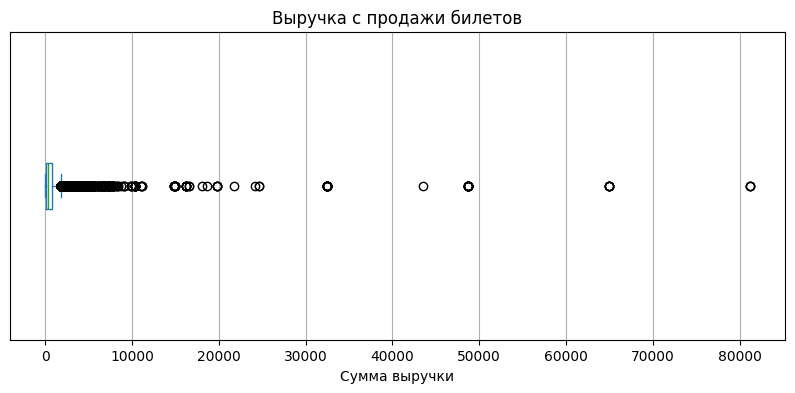

In [14]:
# Исследуем рапсределение выручки с заказов

import matplotlib.pyplot as plt

ax = data[['revenue_rub']].plot(
    kind = 'box',
    vert = False,              # горизонтальный ящик (удобно для сумм)
    grid = True,
    title = 'Выручка с продажи билетов',
    figsize = (10, 4)
)

ax.set_xlabel('Сумма выручки')
ax.set_axisbelow(True)

ax.set_yticks([])
ax.set_ylabel('')

plt.show()

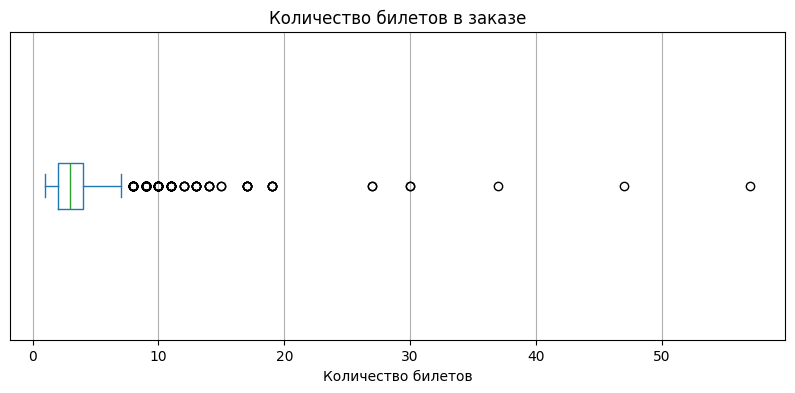

In [15]:
# Исследуем рапсределение количества билетов в заказе

import matplotlib.pyplot as plt

ax = data[['tickets_count']].plot(
    kind = 'box',
    vert = False,              # горизонтальный ящик (удобно для сумм)
    grid = True,
    title = 'Количество билетов в заказе',
    figsize = (10, 4)
)

ax.set_xlabel('Количество билетов')
ax.set_axisbelow(True)

ax.set_yticks([])
ax.set_ylabel('')

plt.show()

Статистические распределения выручки с билетов и количества билетов в заказе имеют очень длинный правый хвост. 

В основном выручка с продажи билетов не превышает 1000 руб, но встречаются и крайне большие значения, например, 20, 65 и даже 80 тысяч. Маловероятно, что эти заказы были совершены одним человеком (достаточно сложно представить себе ситуацию, когда кому-то потребуется выкупить все места в зале). Скорее всего, это массовые закупки билетов для школ или корпоративов, которые не показывают поведение обычного покупателя. Эти данные будут отфильтрованы. Также можно заметить, что присуствуют данные о нулевой выручке. Скорее всего, это не ошибка, так как действительно бывают бесплатные культурные мероприятия.

Большинство покупок билетов, совершённых через сервис, включали от 1 до 7 билетов. Чаще всего люди покупают по 1 билету на себя или по 2-3: для себя и небольшой компании или семьи. Но встречаются и выбросы, включающие в себя информацию о покупке более 50 билетов. Скорее всего, эти случаи не характеризуют поведение обычных клиентов, а свидетельствуют о массовых закупках. Эти данные могут исчезнуть, когда будет проведена фильтрация по выручке, а могут остаться, если массовая закупка коснулась относительно дешёвых билетов.

In [16]:
# Уберём выбросы, оставив значения только в пределах 99 процентилей.

q_99 = data['revenue_rub'].quantile(0.99)
data_trim = data[data['revenue_rub'] <= q_99]

# Посмотрим, какое количество данных было отфильтровано.

abs_trim = data.shape[0] - data_trim.shape[0]
rel_trim = round(100 - (data_trim.shape[0] / data.shape[0]) * 100, 3)

print(f'В ходе фильтрации данных из датафрейма было удалено строк: {abs_trim}. Это составляет {rel_trim}%.')

В ходе фильтрации данных из датафрейма было удалено строк: 2825. Это составляет 0.973%.


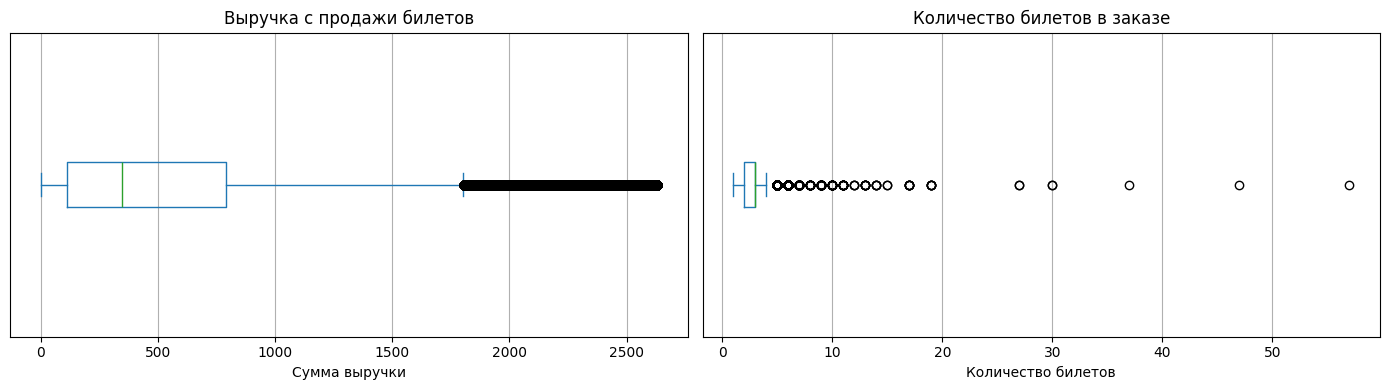

In [17]:
# Теперь посмотрим, как изменилось распределение данных по выручке и количеству купленных билетов

import matplotlib.pyplot as plt

# Разместим 2 графика рядом для экономии места
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (14, 4))

# --- График 1: выручка с продажи билетов ---
data_trim[['revenue_rub']].plot(
    kind = 'box',
    vert = False,
    grid = True,
    ax = axes[0],
    title = 'Выручка с продажи билетов'
)
axes[0].set_xlabel('Сумма выручки')
axes[0].set_axisbelow(True)
axes[0].set_yticks([])
axes[0].set_ylabel('')

# --- График 2: количество билетов ---
data_trim[['tickets_count']].plot(
    kind = 'box',
    vert = False,
    grid = True,
    ax = axes[1],
    title = 'Количество билетов в заказе'
)
axes[1].set_xlabel('Количество билетов')
axes[1].set_axisbelow(True)
axes[1].set_yticks([])
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### Промежуточный вывод

В ходе предобработки данных были проведены следующие важные операции:
- Вся выручка с билетов была приведена к единой валюте — рублю.
- Значения по выручке были отфильтрованы. Во-первых, были убраны отрицательные значения, а во-вторых проведена фильтрация по 99-му процентилю. В результате фильтрации было удалено около 1% строк, зато исчезли аномально большие значения. Теперь диапазон выручки с билетов составляет от 0 до 2600 рублей — это вполне типичный разброс цен на билеты на культурные мероприятия.
- Что интересно, после фильтрации по выручке из данных по билетам не исчезли записи о покупке большого количества билетов. Вероятно, это были очень дешёвые билеты, которые при массовой закупке в итоге не превысили 2600 рублей, или вообще бесплатные билеты.

---
<a id='3'></a>
## 3. Создание профиля пользователя
<a id='3.1'></a>
<b> Задача 3.1. </b> Постройте профиль пользователя — для каждого пользователя найдите:
- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:
- is_two — совершил ли пользователь 2 и более заказа;
- is_five — совершил ли пользователь 5 и более заказов.

In [18]:
# Переназначим имя датафрейма, чтобы больше не путаться с ним

data = data_trim

# Сортируем данные по времени совершения заказа, как и требовалось в задании

data = data.sort_values('order_ts')

# Проводим группировку данных. Для этого нужно создать новый датафрейм grouped_data. Сбрасываем индексы, чтобы не было позже путаницы с названиями

grouped_data = data.groupby('user_id', as_index = False).agg({
    'order_dt': ['min', 'max'],
    'device_type_canonical': 'first',
    'region_name': 'first',
    'service_name': 'first',
    'event_type_main': 'first',
    'order_id': 'count',
    'revenue_rub': 'mean',
    'tickets_count': 'mean',
    'days_since_prev': 'mean'
})

# Переименуем колонки нормально

coulumns = ['user_id', 'order_dt_min', 'order_dt_max', 'device_type_first', 'region_first', 
            'service_first', 'event_first', 'order_count', 'revenue_mean', 'ticket_sum', 'days_between_mean']

grouped_data.columns = coulumns

# Добавляем бинарные признаки

is_two = []
is_five = []

# Заполним массив значениями True или False и добавим столбец в исходный датасет
for count in grouped_data['order_count']:
    if count < 2:
        is_two.append(False)
        is_five.append(False)
    elif count >= 2 and count < 5:
        is_two.append(True)
        is_five.append(False)
    elif count >= 5:
        is_two.append(True)
        is_five.append(True)

# Добавим в датафрейм бинарные признаки
grouped_data['is_two'] = is_two
grouped_data['is_five'] = is_five

In [19]:
# Опционально: поверяем текущее состояние датафрейма
# grouped_data.info()
# grouped_data.head()

<a id='3.2'></a>
<b>Задача 3.2.</b> Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.
Используя данные о профилях пользователей, рассчитайте:
- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:
- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

In [20]:
# Расчитаем требуемые характеристики для пользователей с использованием датафрейма

users_count = grouped_data['user_id'].nunique()
avg_revenue = round(grouped_data['revenue_mean'].mean(), 2)
ratio_2 = round(grouped_data['is_two'].mean(), 2)
ratio_5 = round(grouped_data['is_five'].mean(), 2)

print(f'В выборке присутствуют данные по {users_count} пользователям.\nСредняя выручка с одного заказа составляет {avg_revenue} руб.\nДоля пользователей, который оформили хотя бы 2 заказа, составляет {ratio_2}.\nДоля пользователей, который оформили 5 заказов и более, составляет {ratio_5}.')

В выборке присутствуют данные по 21838 пользователям.
Средняя выручка с одного заказа составляет 545.03 руб.
Доля пользователей, который оформили хотя бы 2 заказа, составляет 0.62.
Доля пользователей, который оформили 5 заказов и более, составляет 0.29.


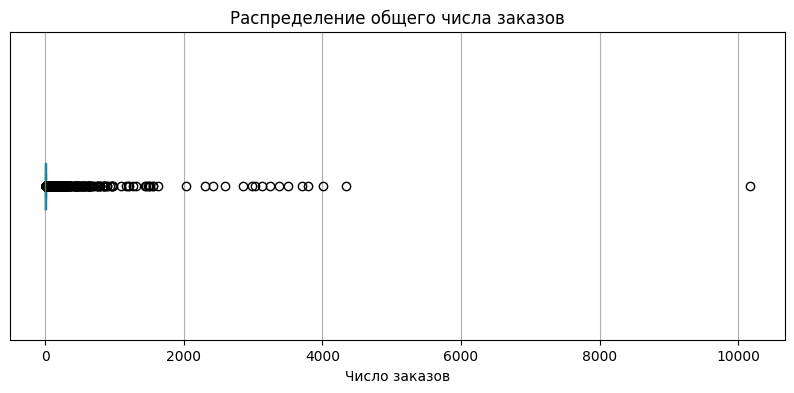

In [21]:
# Исследуем рапсределение общего числа заказов

ax = grouped_data[['order_count']].plot(
    kind = 'box',
    vert = False,              # горизонтальный ящик (удобно для сумм)
    grid = True,
    title = 'Распределение общего числа заказов',
    figsize = (10, 4)
)

ax.set_xlabel('Число заказов')
ax.set_axisbelow(True)

ax.set_yticks([])
ax.set_ylabel('')

plt.show()

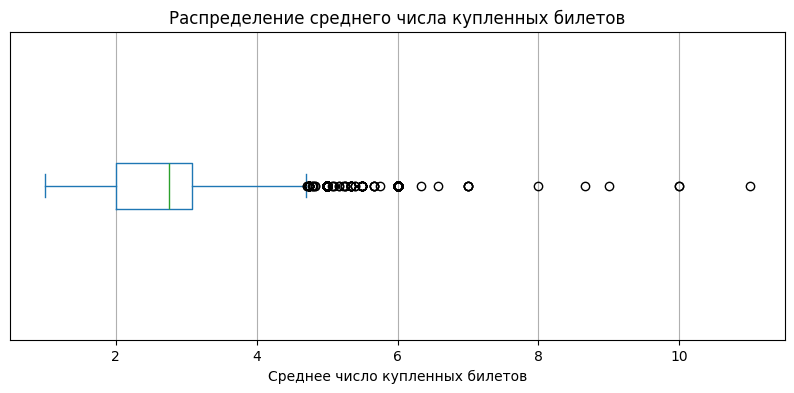

In [22]:
# Исследуем рапсределение общего числа заказов

ax = grouped_data[['ticket_sum']].plot(
    kind = 'box',
    vert = False,              # горизонтальный ящик (удобно для сумм)
    grid = True,
    title = 'Распределение среднего числа купленных билетов',
    figsize = (10, 4)
)

ax.set_xlabel('Среднее число купленных билетов')
ax.set_axisbelow(True)

ax.set_yticks([])
ax.set_ylabel('')

plt.show()

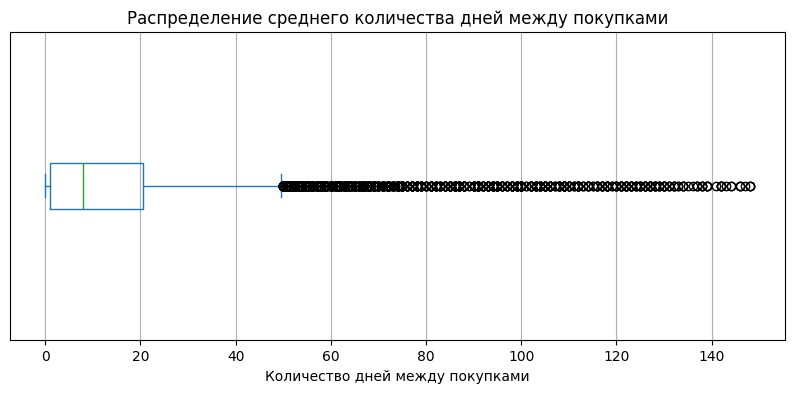

In [23]:
# Исследуем рапсределение общего числа заказов

ax = grouped_data[['days_between_mean']].plot(
    kind = 'box',
    vert = False,              # горизонтальный ящик (удобно для сумм)
    grid = True,
    title = 'Распределение среднего количества дней между покупками',
    figsize = (10, 4)
)

ax.set_xlabel('Количество дней между покупками')
ax.set_axisbelow(True)

ax.set_yticks([])
ax.set_ylabel('')

plt.show()

Проанализируем полученные характеристики.
- Распределение общего числа заказов имеет крайне неестественные выбросы. Трудно представить, чтобы кто-то успел за 5 месяцев оформить 10 000 заказов! Либо это какая-то ошибка, либо скупка билетов осуществлялась ботами. Количество заказов более сотни за 5 месяцев вызывает большие вопросы и не характеризует нормальное человеческое поведение. На мой взгляд, стоит оставить только те данные, где заказов не больше 40-50: вряд ли кто-то посещал культурные мероприятия чаще, чем раз в 3 дня. Для этого проведём фильтрацию по 95-му процентилю.
- Со средним числом билетов в одном заказе ситуация выглядит более реалистично: можно представить единоразовую покупку 10 и даже более билетов для большой компании. Фильтрация по этому параметру не требуется.
- Количество дней между покупками тоже имеет логичное распределение. Большинство людей покупали билеты достаточно часто, иногда даже по нескольку раз за день. Но также встречаются и случаи редких покупок. Число дней между покупками не превышает количество дней в рассматриваемом диапазоне, поэтому здесь фильтрация не нужна.

In [24]:
# Уберём выбросы, оставив значения только в пределах 95 процентилей.

q_95 = grouped_data['order_count'].quantile(0.95)
grouped_data_trim = grouped_data[grouped_data['order_count'] <= q_95]

# Посмотрим, какое количество данных было отфильтровано.

abs_trim = grouped_data.shape[0] - grouped_data_trim.shape[0]
rel_trim = round(100 - (grouped_data_trim.shape[0] / grouped_data.shape[0]) * 100, 3)

print(f'В ходе фильтрации данных из датафрейма было удалено строк: {abs_trim}. Это составляет {rel_trim}%.')

В ходе фильтрации данных из датафрейма было удалено строк: 1091. Это составляет 4.996%.


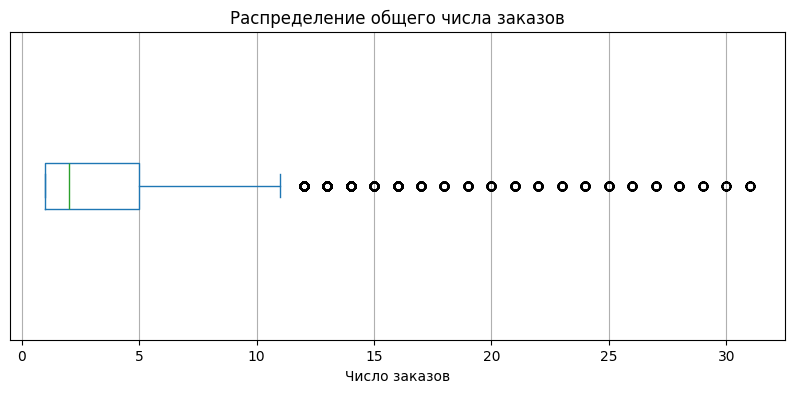

In [25]:
# Исследуем рапсределение общего числа заказов

ax = grouped_data_trim[['order_count']].plot(
    kind = 'box',
    vert = False,              # горизонтальный ящик (удобно для сумм)
    grid = True,
    title = 'Распределение общего числа заказов',
    figsize = (10, 4)
)

ax.set_xlabel('Число заказов')
ax.set_axisbelow(True)

ax.set_yticks([])
ax.set_ylabel('')

plt.show()

Теперь распределение общего числа заказов выглядит вполне правдоподобно. Максимально активные пользователи в отфильтрованной выборке посещали мероприятия в среднем раз в 5 дней — этот результат уже лучше согласуется с поведением человека, который посещает культурные мероприятия каждые выходные.

На всякий случай проверим, как изменились характеристики по пользователям.

In [26]:
# Расчитаем требуемые характеристики для пользователей с использованием датафрейма

users_count = grouped_data_trim['user_id'].nunique()
avg_revenue = round(grouped_data_trim['revenue_mean'].mean(), 2)
ratio_2 = round(grouped_data_trim['is_two'].mean(), 2)
ratio_5 = round(grouped_data_trim['is_five'].mean(), 2)

print(f'В выборке присутствуют данные по {users_count} пользователям.\nСредняя выручка с одного заказа составляет {avg_revenue} руб.\nДоля пользователей, который оформили хотя бы 2 заказа, составляет {ratio_2}.\nДоля пользователей, который оформили 5 заказов и более, составляет {ratio_5}.')

В выборке присутствуют данные по 20747 пользователям.
Средняя выручка с одного заказа составляет 547.3 руб.
Доля пользователей, который оформили хотя бы 2 заказа, составляет 0.6.
Доля пользователей, который оформили 5 заказов и более, составляет 0.25.


### Промежуточный вывод

После проведения группировки данных по пользователям были обнаружены интересные особенности данных:
- В выборке присутствовали аномальные значения по количеству купленных за выбранный временнной период билетов. Из выборки были удалены около 1000 строк (почти 5%), относящихся к пользователям, которые совершили более 32 заказов билетов за 5 месяцев, так как слишком большое количество заказов билетов не похоже на поведение среднестатистического человека.
- В итоговой выборке остались 20747 пользователей. Более половины пользователей оформили хотя бы 2 заказа билетов на площадке. Чуть более четверти пользователей оформили 5 и более заказов. Средняя цена за заказ составляет коло 547 руб.



---
<a id='4'></a>
## 4. Исследовательский анализ данных

<a id='4.1.1'></a>
<b> Задача 4.1.1. </b> Изучите распределение пользователей по признакам.
Сгруппируйте пользователей:
- по типу их первого мероприятия;
- по типу устройства, с которого совершена первая покупка;
- по региону проведения мероприятия из первого заказа;
- по билетному оператору, продавшему билеты на первый заказ.

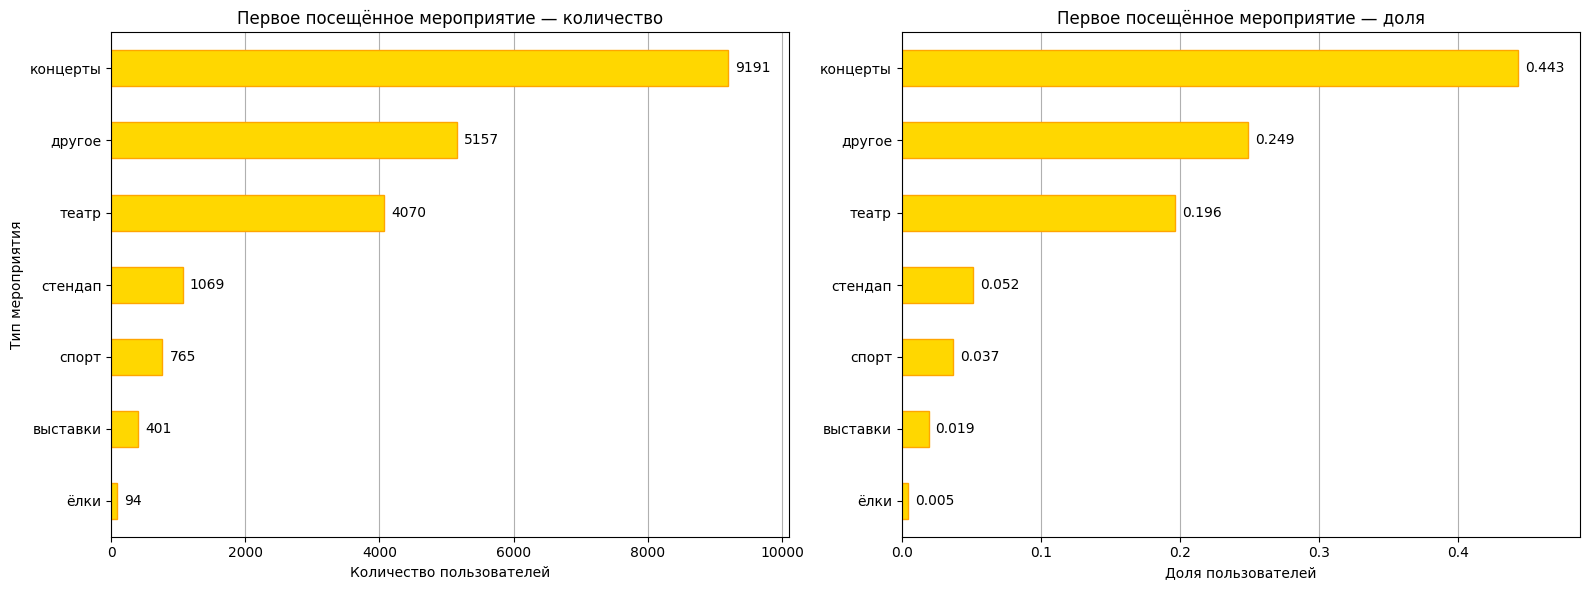

In [27]:
# Данные для графиков
counts = grouped_data_trim['event_first'].value_counts()
shares = grouped_data_trim['event_first'].value_counts(normalize = True)  # доли 0..1

# Разместим 2 графика рядом для экономии места
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

# ----------- График 1: количество -----------
ax1 = counts.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'gold',
    edgecolor = 'orange',
    ax = axes[0],
    title = 'Первое посещённое мероприятие — количество'
)

axes[0].set_xlabel('Количество пользователей')
axes[0].set_ylabel('Тип мероприятия')
axes[0].set_axisbelow(True)
axes[0].grid(True, axis = 'x')

# Подписи на столбиках
axes[0].bar_label(axes[0].containers[0], fmt = '%d', padding = 5, color = 'black')
axes[0].margins(x = 0.10)

# ----------- График 2: доля -----------
ax2 = shares.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'gold',
    edgecolor = 'orange',
    ax = axes[1],
    title = 'Первое посещённое мероприятие — доля'
)

axes[1].set_xlabel('Доля пользователей')
axes[1].set_ylabel('')  # чтобы не дублировать подпись слева
axes[1].set_axisbelow(True)
axes[1].grid(True, axis = 'x')

# Подписи на столбиках
axes[1].bar_label(axes[1].containers[0], fmt = '%.3f', padding = 5, color = 'black')
axes[1].margins(x = 0.10)

plt.tight_layout()
plt.show()

Проанализируем особенности распределения пользователей по типу первого мероприятия, на которое был куплен билет. Стоит отметить, что из числа анализируемых категорий были исключены фильмы, так как количество покупок билетов на фильмы было крайне низким.

- В распределении есть явные лидеры: категории концертов (около половины от первых купленных билетов), театров, и "другое" составляют почти 90% от всех первых покупок. Остальные категории менее популярны, а меньше всего спрос на билеты на ёлки. Это объясняется особенностями временных рамок выборки: спрос на билеты на ёлки обычно очень сезонный, поэтому в выборке за летние и осенние месяцы продажи билетов на ёлки крайне низкие. Зато концерты пользуются большим спросом, так как в тёплое время года открываются площадки для проведения концертов открытого типа (на свежем воздухе). Если бы выборка была за холодное время года, вполне вероятно, что ёлки могли бы иметь большую популярность, чем концерты.
- Категория "другое" сильно снижает интерпретируемость данных: она аггрегирует в себе много мероприятий и может прятать важные подтипы. Для каждого четвёртого пользователя точка входа находится именно в этой категории, но что конкретно привело его в сервис — большой вопрос. На мой взгляд, стоит увеличить количество категорий для более информативной сегментации пользователей.

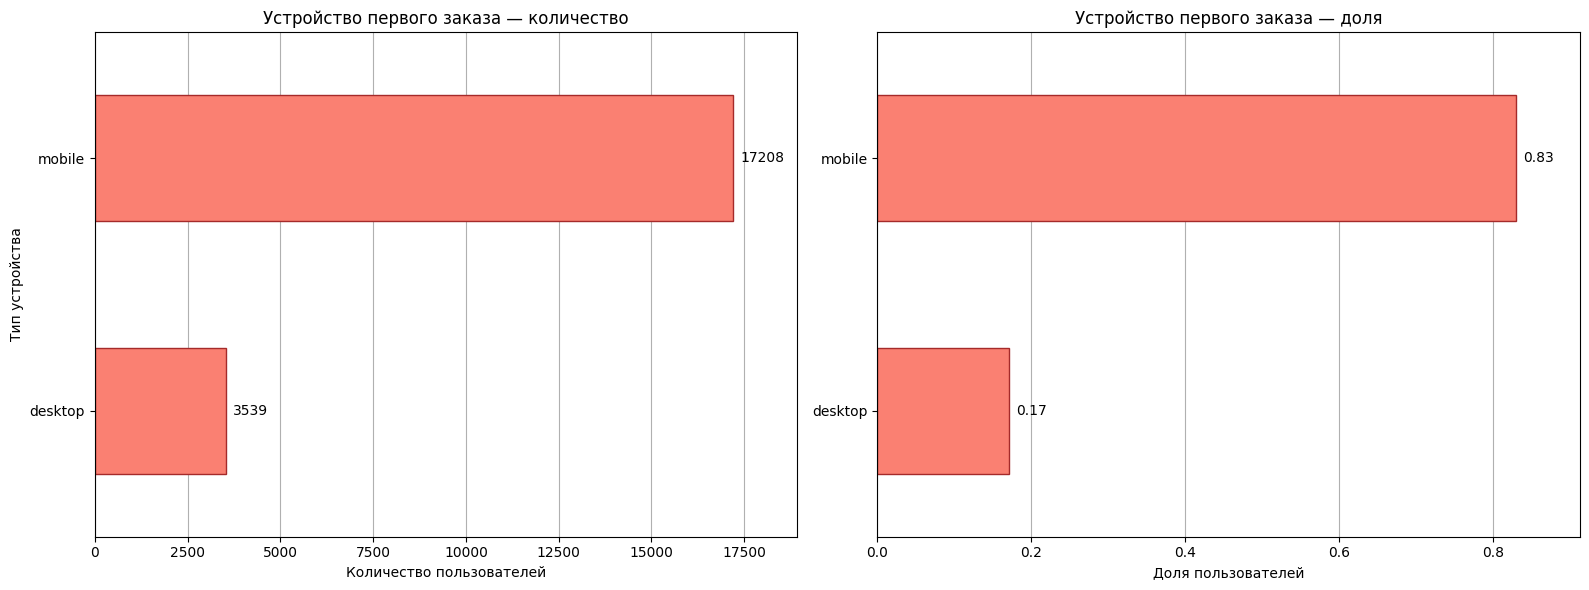

In [28]:
# Данные для графиков
counts = grouped_data_trim['device_type_first'].value_counts()
shares = grouped_data_trim['device_type_first'].value_counts(normalize = True)  # доли 0..1

# Разместим 2 графика рядом для экономии места
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

# ----------- График 1: количество -----------
ax1 = counts.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'salmon',
    edgecolor = 'brown',
    ax = axes[0],
    title = 'Устройство первого заказа — количество'
)

axes[0].set_xlabel('Количество пользователей')
axes[0].set_ylabel('Тип устройства')
axes[0].set_axisbelow(True)
axes[0].grid(True, axis = 'x')

# Подписи на столбиках
axes[0].bar_label(axes[0].containers[0], fmt = '%d', padding = 5, color = 'black')
axes[0].margins(x = 0.10)

# ----------- График 2: доля -----------
ax2 = shares.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'salmon',
    edgecolor = 'brown',
    ax = axes[1],
    title = 'Устройство первого заказа — доля'
)

axes[1].set_xlabel('Доля пользователей')
axes[1].set_ylabel('')  # чтобы не дублировать подпись слева
axes[1].set_axisbelow(True)
axes[1].grid(True, axis = 'x')

# Подписи на столбиках
axes[1].bar_label(axes[1].containers[0], fmt = '%.2f', padding = 5, color = 'black')
axes[1].margins(x = 0.10)

plt.tight_layout()
plt.show()

Проанализируем особенности распределения пользователей по типу устройства, через которое был куплен первый билет. В выборке были оставлены только случаи покупок билетов через компьютеры и мобильные устройства — в исходных данных встречались и другие варианты устрйоств, но их доля была крайне низкой и они были исключены из анализа.

- Более 80% пользователей покупали свой первый билет через мобильные устройства. Возможно, этому способствовала простота оформления мобильной версии сервиса для покупки билетов или возможность быстрого бронирования билетов.
- Первый билет с компьютера оформили около 17% пользоваетелей.

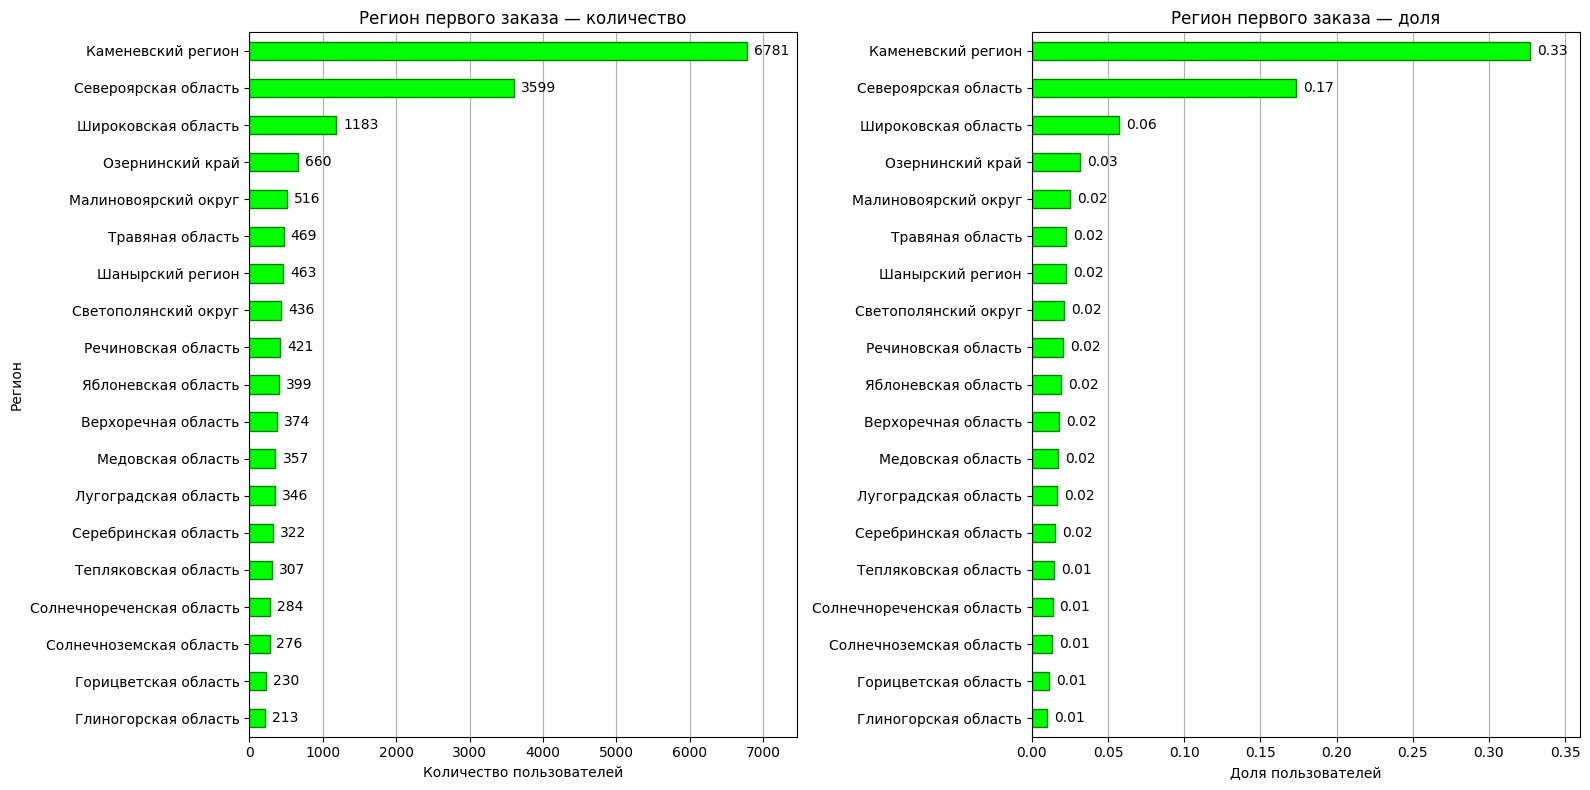

In [29]:
# Данные для графиков (сначала считаем)
counts_all = grouped_data_trim['region_first'].value_counts()
shares_all = grouped_data_trim['region_first'].value_counts(normalize = True)  # доли 0..1

# Я решила оставить регионы только с долей >= 1%, потому что иначе на графике начинается хаос
shares = shares_all[shares_all >= 0.01]
counts = counts_all.loc[shares.index]   

# Разместим 2 графика рядом для экономии места
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 8))

# ----------- График 1: количество -----------
ax1 = counts.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'lime',
    edgecolor = 'green',
    ax = axes[0],
    title = 'Регион первого заказа — количество'
)

axes[0].set_xlabel('Количество пользователей')
axes[0].set_ylabel('Регион')
axes[0].set_axisbelow(True)
axes[0].grid(True, axis = 'x')

# Подписи на столбиках
axes[0].bar_label(axes[0].containers[0], fmt = '%d', padding = 5, color = 'black')
axes[0].margins(x = 0.10)

# ----------- График 2: доля -----------
ax2 = shares.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'lime',
    edgecolor = 'green',
    ax = axes[1],
    title = 'Регион первого заказа — доля'
)

axes[1].set_xlabel('Доля пользователей')
axes[1].set_ylabel('')  # чтобы не дублировать подпись слева
axes[1].set_axisbelow(True)
axes[1].grid(True, axis = 'x')

# Подписи на столбиках
axes[1].bar_label(axes[1].containers[0], fmt = '%.2f', padding = 5, color = 'black')
axes[1].margins(x = 0.10)

plt.tight_layout()
plt.show()

Проанализируем особенности распределения пользователей по региону, в котором был куплен первый билет на мероприятие. Из визуализации были исключены регионы, для которых доля пользователей составляла менее 1%. Таким образом, на графике представлены только те регионы, в которых сервисом действительно пользуются хотя бы несколько сотен человек.

- В выборке есть три явно доминирующих региона: каждый третий билет был куплен в Каменевском регионе, каждый второй билет — в Каменевском регионе или Североярской области. Вместе с Широковской областью эти три региона привели более половины (56%) пользователей для первой покупки билета в выбранном временном интервале.
- Доли остальных регионов крайне низкие: в них сервисом воспользовались только несколько сотен человек.

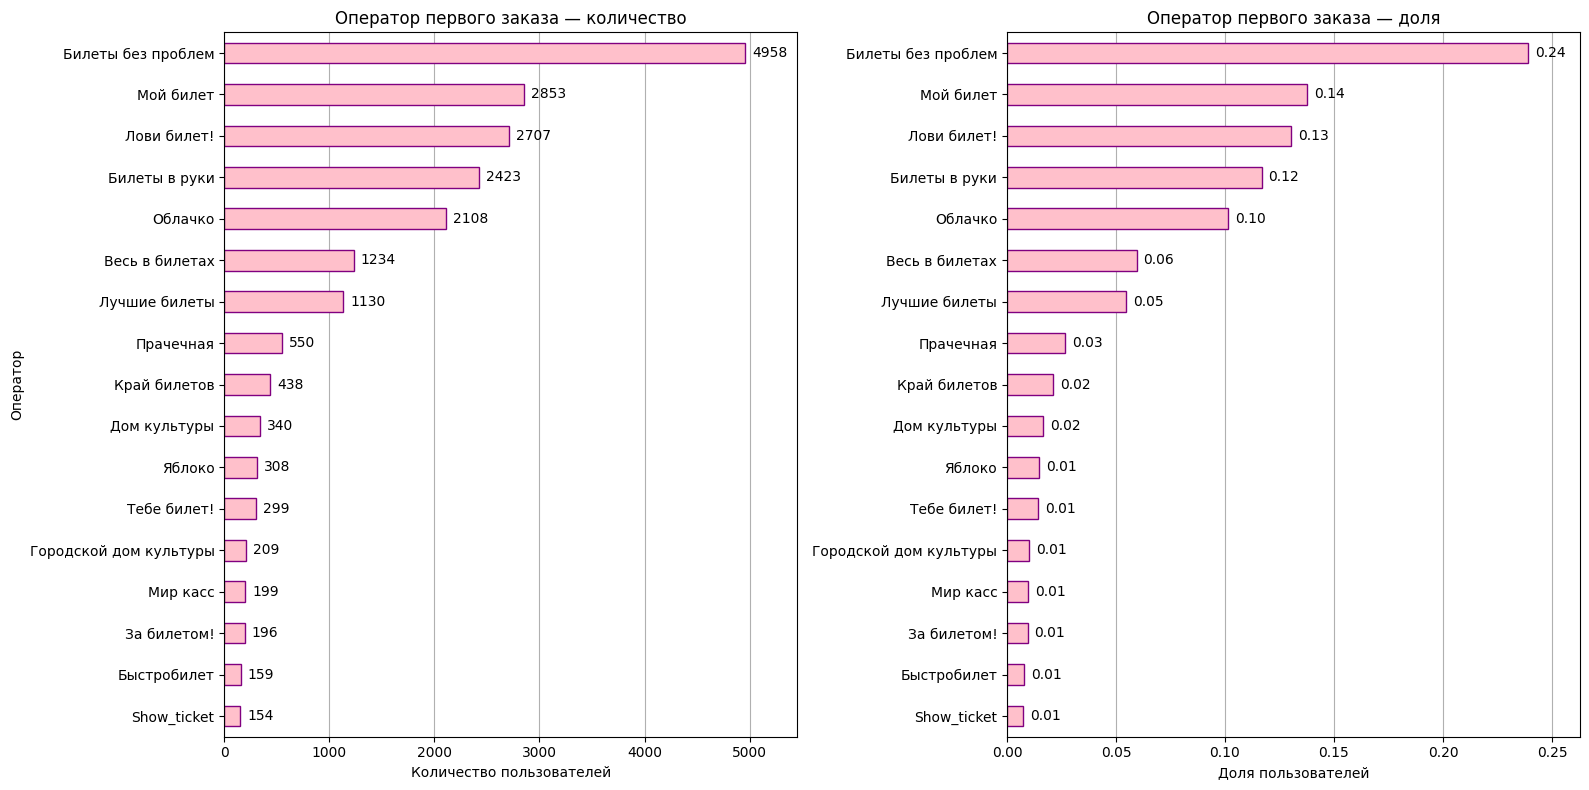

In [30]:
# Данные для графиков (сначала считаем)
counts_all = grouped_data_trim['service_first'].value_counts()
shares_all = grouped_data_trim['service_first'].value_counts(normalize = True)  # доли 0..1

# Также, как и в случае с регионами, я решила оставить операторов только с долей >= 0.5%, потому что иначе на графике начинается хаос
shares = shares_all[shares_all >= 0.005]
counts = counts_all.loc[shares.index]   

# Разместим 2 графика рядом для экономии места
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 8))

# ----------- График 1: количество -----------
ax1 = counts.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'pink',
    edgecolor = 'purple',
    ax = axes[0],
    title = 'Оператор первого заказа — количество'
)

axes[0].set_xlabel('Количество пользователей')
axes[0].set_ylabel('Оператор')
axes[0].set_axisbelow(True)
axes[0].grid(True, axis = 'x')

# Подписи на столбиках
axes[0].bar_label(axes[0].containers[0], fmt = '%d', padding = 5, color = 'black')
axes[0].margins(x = 0.10)

# ----------- График 2: доля -----------
ax2 = shares.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'pink',
    edgecolor = 'purple',
    ax = axes[1],
    title = 'Оператор первого заказа — доля'
)

axes[1].set_xlabel('Доля пользователей')
axes[1].set_ylabel('')  # чтобы не дублировать подпись слева
axes[1].set_axisbelow(True)
axes[1].grid(True, axis = 'x')

# Подписи на столбиках
axes[1].bar_label(axes[1].containers[0], fmt = '%.2f', padding = 5, color = 'black')
axes[1].margins(x = 0.10)

plt.tight_layout()
plt.show()

Проанализируем особенности распределения пользователей по билетному оператору, через которого был куплен первый билет на мероприятие. На графике отсутствуют операторы, через которых было оформлено менее 0.5% всех первых билетов, так как в исследовательском анализе основной интерес представляет анализ наиболее популярных точек входа пользователей.

- Как показывает визуализация, каждый четвёртый билет был куплен через оператора "Билеты без проблем", а три четверти всех купленных первых билетов за рассматриваемый временной промежуток были оформлены через топ-5 билетных операторов.
- При этом билетный оператор "Билеты без проблем" сильно выделяется на фоне остальных операторов топ-5, а вот доли покупок для позиций со второй по пятую практически не отличаются.

### Промежуточный вывод

Точки входа клиентов на Яндекс Афишу за период с 1 июня по 31 октября 2024 года распределены неравномерно. Чаще всего пользователи входили через мобильные устройства для покупки билетов на концерты, в театры и на категорию "другое". Большой популяностью среди пользователей пользовались билетные операторы "Билеты без проблем", "Мой билет", "Лови билет!", "Билеты в руки" и "Облачко", а самый большой спрос на покупку билетов на культурные мероприятия отмечался в Каменевском регионе, Североярской области и Широковской области.

<a id='4.1.2'></a>
<b> Задача 4.1.2. </b> Проанализируйте возвраты пользователей:
- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.

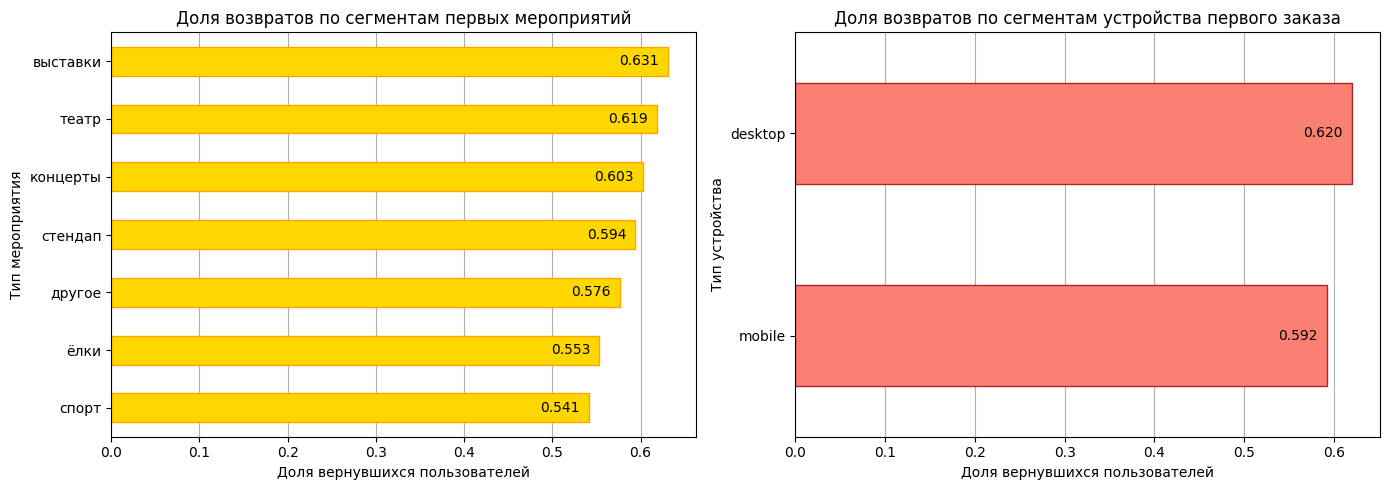

In [31]:
# Разместим 2 графика рядом для экономии места
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (14, 5))

# ----------- График 1: возвраты внутри категорий первого посещённого мероприятия -----------
ax00 = grouped_data_trim.groupby('event_first')['is_two'].mean().sort_values(ascending = True).plot(
               kind = 'barh', 
               legend = False, 
               color = 'gold',
               edgecolor = 'orange',
               ax = axes[0],
               title = 'Доля возвратов по сегментам первых мероприятий'
    )

# Наводим красоту
axes[0].set_xlabel('Доля вернувшихся пользователей')
axes[0].set_ylabel('Тип мероприятия')
axes[0].set_axisbelow(True)
ax00.set_axisbelow(True)
ax00.grid(True, axis = 'x')
ax00.bar_label(ax00.containers[0], fmt = '%.3f', padding = -35, color = 'black')

# ----------- График 2: возвраты внутри устрйоства первого заказа -----------
ax01 = grouped_data_trim.groupby('device_type_first')['is_two'].mean().sort_values(ascending = True).plot(
               kind = 'barh', 
               legend = False, 
               color = 'salmon',
               edgecolor = 'brown',
               ax = axes[1],
               title = 'Доля возвратов по сегментам устройства первого заказа'
    )

# Наводим красоту
axes[1].set_xlabel('Доля вернувшихся пользователей')
axes[1].set_ylabel('Тип устройства')
axes[1].set_axisbelow(True)
ax01.set_axisbelow(True)
ax01.grid(True, axis = 'x')
ax01.bar_label(ax01.containers[0], fmt = '%.3f', padding = -35, color = 'black')

plt.tight_layout()
plt.show()

Проанализируем полученные результаты. В первую очередь, стоит заметить, что результаты сегментации по типу первого посещённого мероприятия и устройствам не демонстрируют каких-то особых точек входа: ни в одной из этих сегментаций не наблюдается сегментов, которые бы значительно превосходили остальные по показателю возвращаемости пользователей. Различия в показателях возвращаемости между крайними сегментами не превышают 10%, а различия между соседними сегментами могут составлять менее 1%. Показатели возвращаемости ни по одному из сегментов не превышают 65%. В среднем, можно сказать, что каждый второй пользователь Яндекс Афиши возвращался для приобретения хотя бы ещё одного билета.

- В сегментации по типам мероприятий чаще всего возвращаются пользователи, которые взяли свой первый билет на выставку или в театр. Меньше всего возвращаемость у пользователей, которые приобретали билеты на ёлки и на спортивные мероприятия. Стоит вспомнить, что больше всего первых билетов было приобретено на концерт — эта категория занимает третье место по возвращаемости. Зависимость возвращаемости от типа первого посещённого мероприятия выражена не сильно, так как показатели по разным сегментам сопоставимы и имеют отличия в пределах одного десятка процентов.
- Доля возвратов пользователей практически не зависит от типа устройства: показатели возвращаемости отличаются всего на 3%. Скорее всего, это говорит о том, что интерфейс площадки одинаково хорошо адаптирован под разные устройства, поэтому можно легко купить билет как через телефон, так и через компьютер.

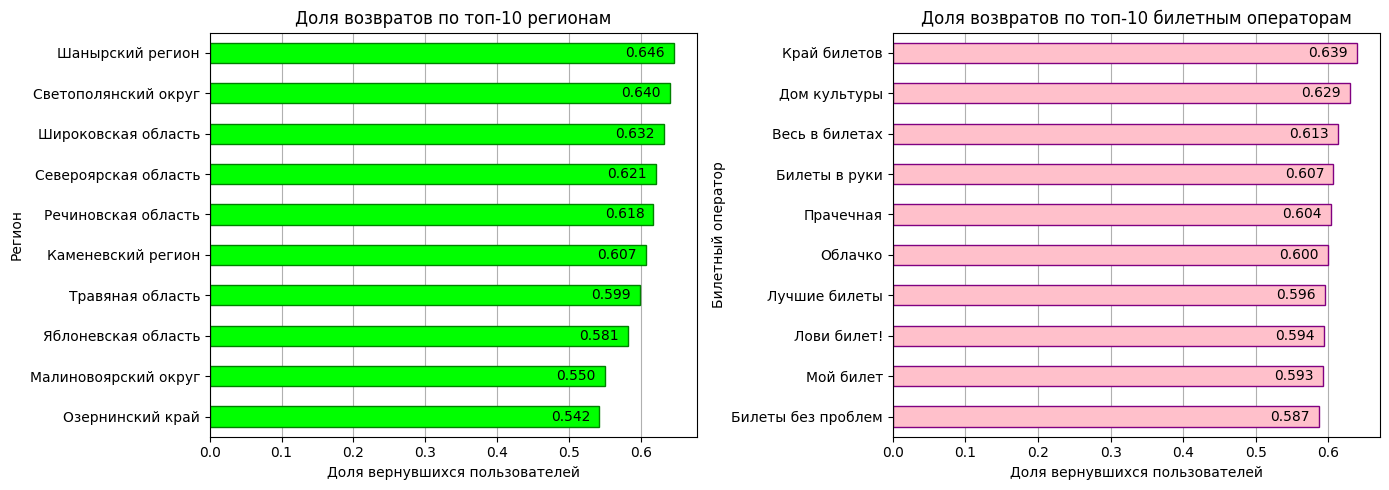

In [32]:
# Определяем топ-10 сегментов по числу пользователей в них
top10_regions = grouped_data_trim['region_first'].value_counts().head(10).index
top10_operators = grouped_data_trim['service_first'].value_counts().head(10).index


# Считаем долю возврата только по этим сегментам 
share_by_regions = grouped_data_trim.groupby('region_first')['is_two'].mean().loc[top10_regions]
share_by_operators = grouped_data_trim.groupby('service_first')['is_two'].mean().loc[top10_operators]

# Разместим 2 графика рядом для экономии места
fig, axes = plt.subplots(nrows = 1, ncols =2 , figsize = (14, 5))

# ------------ График 1: возвраты по топ-10 регионов ------------
ax00 = share_by_regions.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'lime',
    edgecolor = 'green',
    ax = axes[0],
    title = 'Доля возвратов по топ-10 регионам'
)

axes[0].set_xlabel('Доля вернувшихся пользователей')
axes[0].set_ylabel('Регион')
axes[0].set_axisbelow(True)
ax00.grid(True, axis='x')
ax00.bar_label(ax00.containers[0], fmt = '%.3f', padding = -35, color = 'black')

# ------------ График 2: возвраты по топ-10 device_type_first ------------
ax01 = share_by_operators.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'pink',
    edgecolor = 'purple',
    ax = axes[1],
    title = 'Доля возвратов по топ-10 билетным операторам'
)

axes[1].set_xlabel('Доля вернувшихся пользователей')
axes[1].set_ylabel('Билетный оператор')
axes[1].set_axisbelow(True)
ax01.grid(True, axis='x')
ax01.bar_label(ax01.containers[0], fmt = '%.3f', padding = -35, color = 'black')

plt.tight_layout()
plt.show()


Проанализируем полученные результаты. Стоит сразу отметить, что в сегментации по регионам и билетным операторам были оставлены только топ-10 сегментов по возвращаемости. В этих двух сегментациях доли возвращающихся пользователей варьирут сильнее, но в рамках этого исследовательского анализа данных нас интересуют только те сегменты, в которых пользователи возвращаются чаще всего.
- В сегментации по регионам топ-3 региона по количеству первых заказов пользователей (Каменевский регион, Североярская область, Широковская область) находятся в топе по возвращаемости пользователей. На лидирующих позициях по возвращаемости клиентов находятся Шанырский и Светлополянский округа, в которых было совершено порядка 450 первых покупок: несмотря на малое количество клиентов и сравнительно низкий спрос на билеты на культурные мероприятия, эти два округа удерживают чуть больше клиентов, чем самые населённые регионы. Низкие показатели возвратов для регионов в конце топа могут быть объяснены меньшим количеством покупок в них — чем менее популярен в регионе сервис, тем меньше шанс, что пользователи вернутся.
- Вероятность возврата пользователей довольно слабо зависит от типа билетного оператора: в пределах топ-10 операторов различия в вероятности не превышают 5%. Скорее всего, пользователи не особо обращают внимание на название самого билетного оператора: в первую очередь их интересуют цены и доступность билетов. В топ-10 по возвращаемости вошли топ-5 операторов по количеству покупок первых билетов: "Билеты без проблем", "Мой билет", "Лови билет!", "Билеты в руки" и "Облачко".

### Промежуточный вывод

Вероятность возврата клиентов слабо варьирует в пределах сегментаций по типу первого мероприятия и устройства первого заказа. Для сегментации по регионам и билетным операторам отличия также незначительные. Также интерпретацию результатов затрудняет количество пользователей в каждом сегменте: оно очень сильно разнится.

Можно сказать, что первое впечатление пользователей о Яндекс Афише примерно одинаковое несмотря на регион, тип устройства просмотра сервиса или цель покупки билета.

<a id='4.1.3'></a>
<b> Задача 4.1.3. </b> Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

<b> Гипотеза 1. </b> Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

<b> Гипотеза 2. </b> В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

### Гипотеза 1

Тип мероприятия действительно влияет на вероятность возврата пользователей на Яндекс Афишу, но не определяет его. Стоит иметь в виду разность по выборке: пользователей, который купили свой первый билет на концерт, почти в 10 раз больше, чем пользователей, которые купили свой первый билет на спортивное мероприятие: хотя по расчётам доля вернувшихся пользователей среди купивших билет на концерт на 6% больше, вывод интерпретируется сложно. 

Лучше выразить вывод так: Яндекс Афиша часто используется как платформа для покупки билетов на концерты, поэтому пользователи, которые купили первый билет на концерт, вернутся с чуть большей вероятностью. Однако это не доказывает причинность возвратов.

### Гипотеза 2

Это действительно так: топ-3 региона по количеству покупок билетов присутствовали в топ-6 регионов по доле возвращающихся клиентов. А регионы, которые по количеству покупок билетов находились в конце топа (или были исключены из него из-за крайне низкого числа покупок) не встретились в топе по доле возвращающихся клиентов. 

<a id='4.2.1'></a>
<b> Задача 4.2.1. </b> Проследите связь между средней выручкой сервиса с заказа и повторными заказами.
Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
- для пользователей, совершивших один заказ;
- для вернувшихся пользователей, совершивших 2 и более заказа.

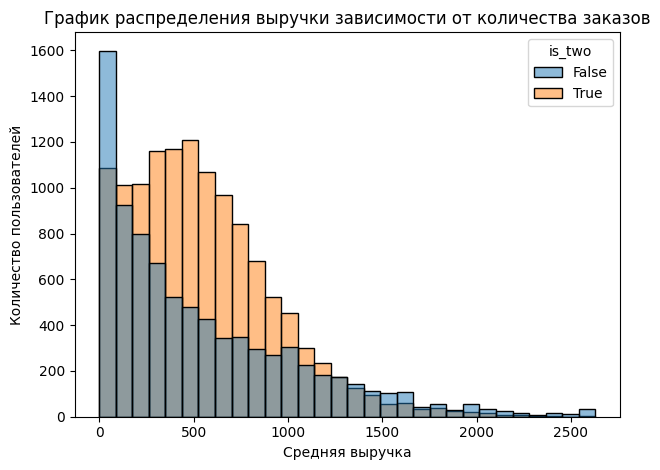

In [33]:
# Сравним распределение для пользователей, которые совершили один заказ, с распределением пользователей которые 

sns.histplot(data = grouped_data_trim, x = 'revenue_mean', bins = 30, hue = 'is_two')

plt.title('График распределения выручки зависимости от количества заказов')
plt.xlabel('Средняя выручка')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()

### Краткий вывод

Распределение выручки с пользователей сильно меняется в зависимости от того, сколько заказов они совершали. Пользователи, которые не совершали повторных заказов, чаще всего приходят на Яндекс Афишу за очень дешёвыми или бесплатными билетами, поэтому средняя выручка по ним тяготеет к 0 и низким значениям. Количество пользователей, которые купили единственный билет, закономерно уменьшается с увеличением цены. Чем более дорогие билеты — тем меньше вероятность, что пользователь, который пришёл на сервис впервые, купит их.

Для пользователей, которые покупали билеты несколько раз, всё ещё заметна тенденция к приобретению дешёвых или бесплатных билетов, однако, после первого положительного опыта с сервисом, их доверие постепенно увеличивается, и увеличивается сумма, которую они готовы доверить сервису за один заказ.

<a id='4.2.2'></a>
<b> Задача 4.2.2. </b> Сравните распределение по средней выручке с заказа в двух группах пользователей:
- совершившие 2-4 заказа;
- совершившие 5 и более заказов.

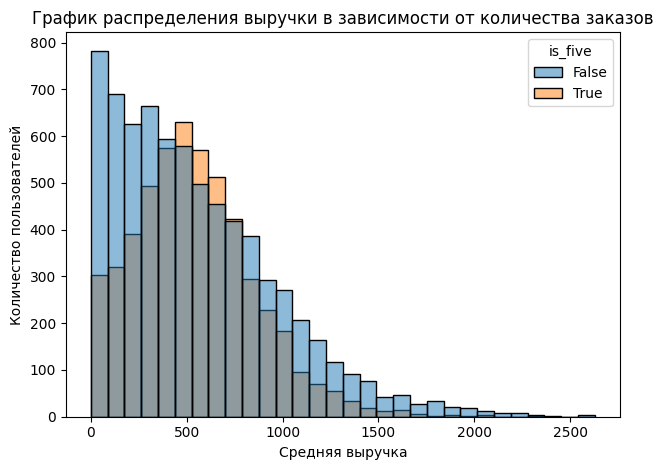

In [34]:
# Исключаем из рассмотрения пользователей, которые покупали билет всего 1 раз

returned_clients = grouped_data_trim[grouped_data_trim['is_two'] == True]

sns.histplot(data = returned_clients, x = 'revenue_mean', bins = 30, hue = 'is_five')

plt.title('График распределения выручки в зависимости от количества заказов')
plt.xlabel('Средняя выручка')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()

### Краткий вывод

При разделении на 2-4 заказа и 5 и более заказов наблюдается ситуация, похожая на ту, что была при предудщем сравнении видов распределения.

Можно заметить, что среди пользователей, которые вернулись на Яндекс Афишу, те, у которых заказов меньше, чаще всего интересуются более дешёвыми билетами, хотя и зависимость от цены уже не такая резкая. 

Средняя выручка среди пользователей, которые совершили 5 и более заказов, имеет явно выраженный максимум возле значения 500. Это значит, что средняя сумма, которую пользователи тратят на билет, постепенно растёт с увеличением количества заказов: это может быть связано либо с изменением ценового сегмента билетов (то есть покупки более дорогих билетов), либо с приобретением большего количества билетов.

<a id='4.2.3'></a>
<b> Задача 4.2.3. </b> Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.
Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
- от 1 до 2 билетов;
- от 2 до 3 билетов;
- от 3 до 5 билетов;
- от 5 и более билетов.
  
Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.

In [35]:
# Создадим отдельный датафрейм специально для этого расчёта

segmented_data = pd.DataFrame()
segmentation = []

for number in grouped_data_trim['ticket_sum']:
    if number < 2:
        segmentation.append('От 1 до 2 билетов')
    elif number >= 2 and number < 3:
        segmentation.append('От 2 до 3 билетов')
    elif number >= 3 and number < 5:
        segmentation.append('От 3 до 5 билетов')
    elif number >= 5:
     segmentation.append('От 5 и более билетов')
        
segmented_data[['user_id', 'is_two']] = grouped_data_trim[['user_id', 'is_two']]
segmented_data['segmentation'] = segmentation

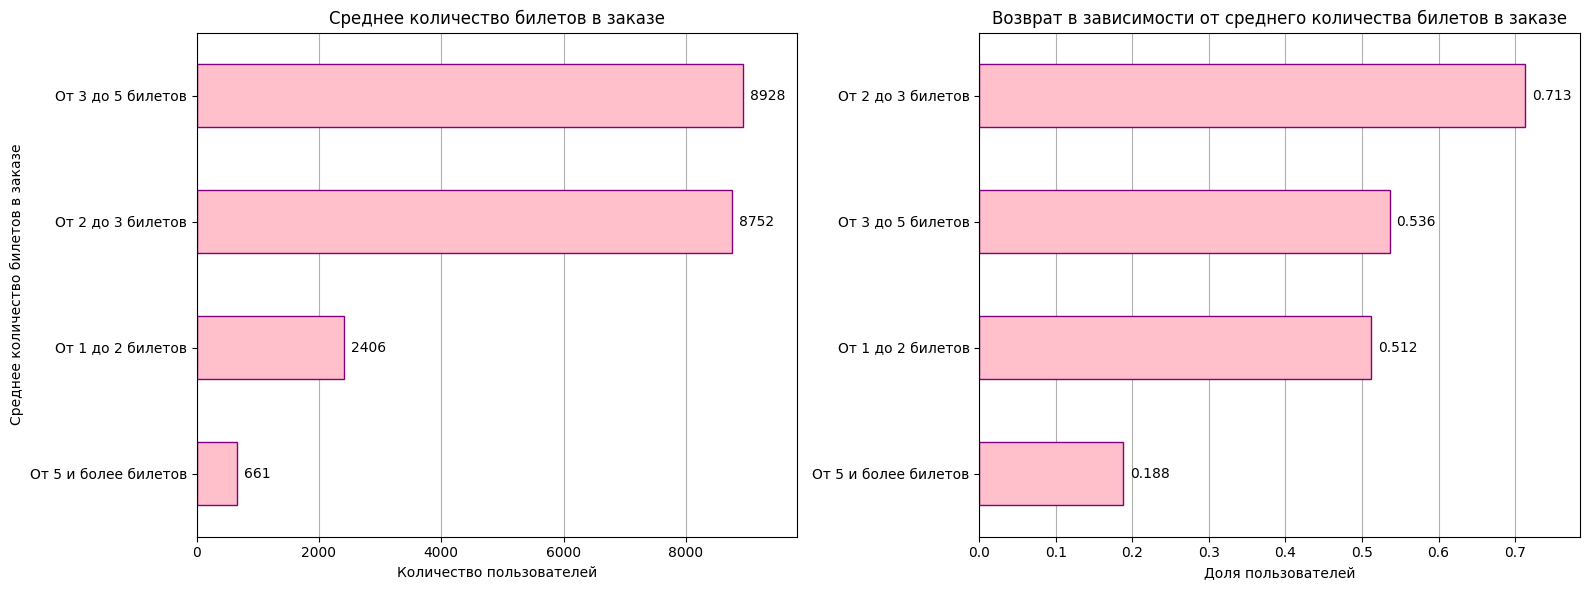

In [36]:
# Данные для графиков
counts = segmented_data['segmentation'].value_counts()
shares = segmented_data.groupby('segmentation')['is_two'].mean() 

# Разместим 2 графика рядом для экономии места
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

# ----------- График 1: количество -----------
ax1 = counts.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'pink',
    edgecolor = 'purple',
    ax = axes[0],
    title = 'Среднее количество билетов в заказе'
)

axes[0].set_xlabel('Количество пользователей')
axes[0].set_ylabel('Среднее количество билетов в заказе')
axes[0].set_axisbelow(True)
axes[0].grid(True, axis = 'x')

# Подписи на столбиках
axes[0].bar_label(axes[0].containers[0], fmt = '%d', padding = 5, color = 'black')
axes[0].margins(x = 0.10)

# ----------- График 2: доля пользователей, которые вернулись -----------
ax2 = shares.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'pink',
    edgecolor = 'purple',
    ax = axes[1],
    title = 'Возврат в зависимости от среднего количества билетов в заказе'
)

axes[1].set_xlabel('Доля пользователей')
axes[1].set_ylabel('')  # чтобы не дублировать подпись слева
axes[1].set_axisbelow(True)
axes[1].grid(True, axis = 'x')

# Подписи на столбиках
axes[1].bar_label(axes[1].containers[0], fmt = '%.3f', padding = 5, color = 'black')
axes[1].margins(x = 0.10)

plt.tight_layout()
plt.show()

### Краткий вывод

Пользователи распределены по сегментам неравномерно.

Типичный пользователь, оформлявший заказ на Яндекс Афише за выделенный промежуток времени, приобретал от 2 до 5 билетов: категории "от 2 до 3 билетов" и "от 3 до 5 билетов" практически одинаковы по размеру. И именно эти пользователи имеют наибольшие вероятности возврата: 0.7 и 0.5 соответственно. Пользователи, которые приобретают 2-3 билета, являются самыми регулярными: это наиболее удобный формат покупки билетов для пары, семьи или небольшой компании.

Пользователи, которые в среднем за один заказ приобретали более 5 билетов, встречаются достаточно редко, и для них вероятность возврата наименьшая: всего 0.2. Этот сегмент может быть выражен разовыми групповыми или корпоративными покупками, поэтому он имеет более низкую повторяемость.

<a id='4.3.1'></a>
<b> Задача 4.3.1. </b> 

Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.
- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.

In [37]:
# Вместо присоединения нового столбца к исходному датасету, создадим новый, в который перенесём только нужные даты

weekday_data = pd.DataFrame()
weekday_data[['user_id', 'is_two']] = grouped_data_trim[['user_id', 'is_two']]
weekday_data['weekday'] = grouped_data_trim['order_dt_min'].dt.weekday + 1 # Добавляем +1 чтобы понедельник был 1, а не 0

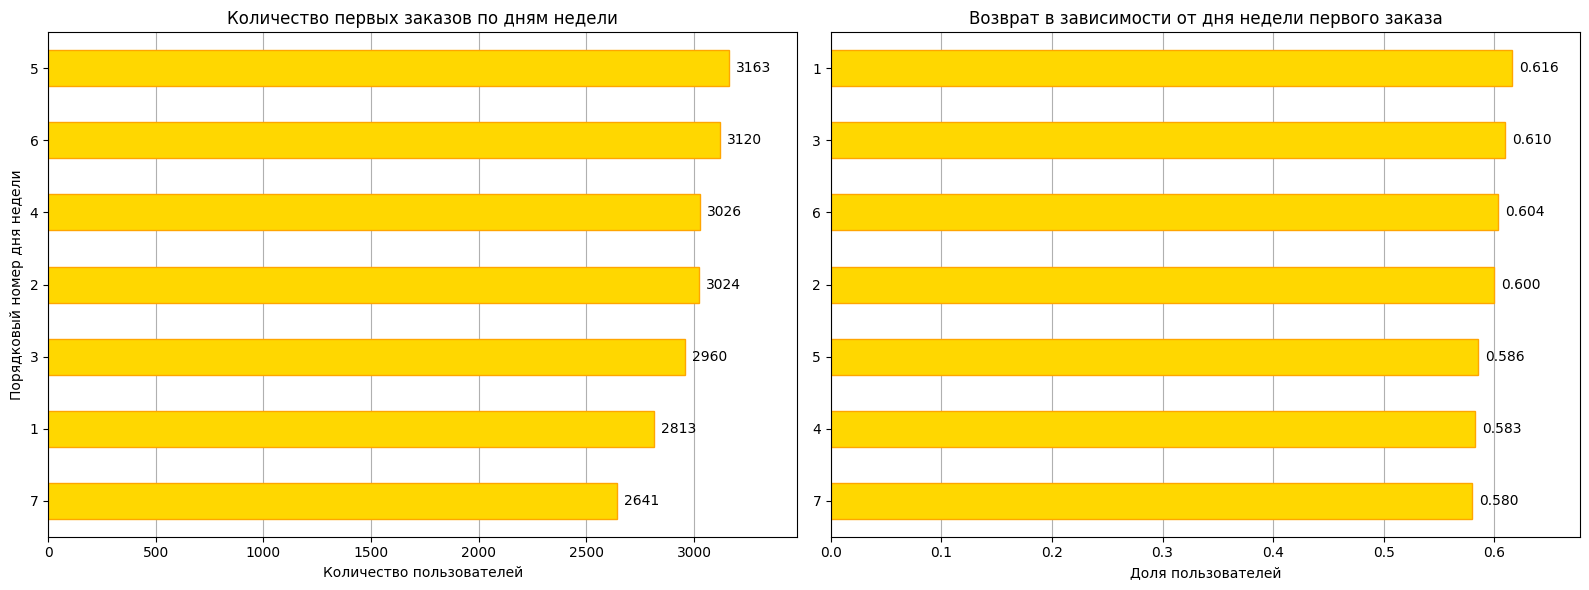

In [38]:
# Сначала собираем данные для графиков
counts_w = weekday_data['weekday'].value_counts()
shares_w = weekday_data.groupby('weekday')['is_two'].mean() 

# Разместим 2 графика рядом для экономии места
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

# ----------- График 1: количество -----------
ax1 = counts_w.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'gold',
    edgecolor = 'orange',
    ax = axes[0],
    title = 'Количество первых заказов по дням недели'
)

axes[0].set_xlabel('Количество пользователей')
axes[0].set_ylabel('Порядковый номер дня недели')
axes[0].set_axisbelow(True)
axes[0].grid(True, axis = 'x')

# Подписи на столбиках
axes[0].bar_label(axes[0].containers[0], fmt = '%d', padding = 5, color = 'black')
axes[0].margins(x = 0.10)

# ----------- График 2: доля вернувшихся пользователей -----------
ax2 = shares_w.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'gold',
    edgecolor = 'orange',
    ax = axes[1],
    title = 'Возврат в зависимости от дня недели первого заказа'
)

axes[1].set_xlabel('Доля пользователей')
axes[1].set_ylabel('')  # чтобы не дублировать подпись слева
axes[1].set_axisbelow(True)
axes[1].grid(True, axis = 'x')

# Подписи на столбиках
axes[1].bar_label(axes[1].containers[0], fmt = '%.3f', padding = 5, color = 'black')
axes[1].margins(x = 0.10)

plt.tight_layout()
plt.show()

### Краткий вывод

Количество первых заказов билетов имеет некоторую зависимость от дней недели: чаще всего пользователи приобретали билеты на Янекс Афише в пятницу, в субботу и в четверг. Скорее всего, это связано с тем, что большинство пользователей планируют посещение культурных мероприятий на выходные, поэтому приобретают билеты непосредственно за один-два дня до мероприятия.

Покупка билетов в определённый день недели не определяет возврат пользователей: разница между минимальным и максимальным показателем возврата составляет всего 3%. Разница в доле вернувшихся пользователей очень мала, поэтому можно сделать вывод, что день недели не является причиной возврата пользователей на платформу.

<a id='4.3.2'></a>
<b> Задача 4.3.2.</b> Изучите, как средний интервал между заказами влияет на удержание клиентов.
Рассчитайте среднее время между заказами для двух групп пользователей:
- совершившие 2-4 заказа;
- совершившие 5 и более заказов.

In [39]:
segmented_data_orders = pd.DataFrame()
segmentation_orders = []

# Воспользуемся данными returned_clients, которые содержат записи только о тех клиентах, которые вернулись

for row in returned_clients[['is_two', 'is_five']].itertuples(index = False): # Построчно перебираем строчки датасета и осуществляем сегментацию
    is_two, is_five = row.is_two, row.is_five
    if is_two and (not is_five):
        segmentation_orders.append('2-4 заказа')
    elif is_five:
        segmentation_orders.append('5 и более заказов')

segmented_data_orders[['user_id', 'days_between_mean']] = returned_clients[['user_id', 'days_between_mean']]
segmented_data_orders['segmentation_orders'] = segmentation_orders

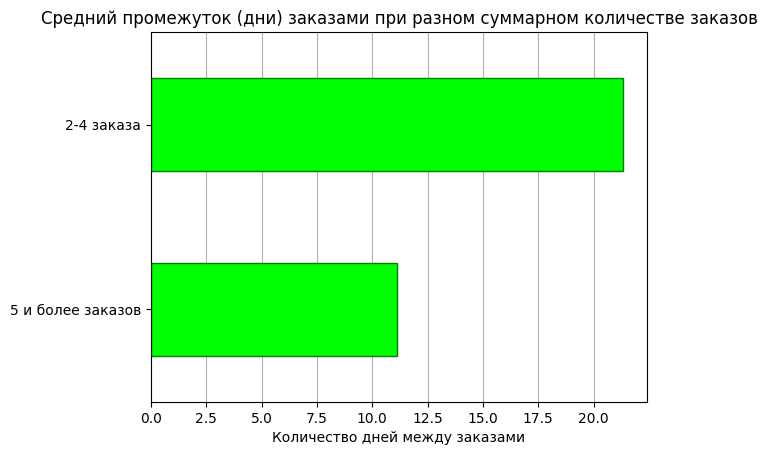

In [40]:
# Данные для графика

shares_o = segmented_data_orders.groupby('segmentation_orders')['days_between_mean'].mean() 

# Построение графика

ax = shares_o.sort_values(ascending = True).plot(
    kind = 'barh',
    legend = False,
    color = 'lime',
    edgecolor = 'green',
    title = 'Средний промежуток (дни) заказами при разном суммарном количестве заказов'
)

ax.set_xlabel('Количество дней между заказами')
ax.set_ylabel('')
ax.set_axisbelow(True)
ax.grid(True, axis = 'x')

### Краткий вывод

Между количеством заказов пользователей и промежутком между заказами действительно имеется связь: чем больше заказов совершали пользователи, тем меньше дней проходило между заказами. На мой взгляд, не совсем правильно говорить, что средний интервал между заказами влияет на вероятность повторного заказа: это путаница между причиной и следствием. Средний интервал между заказами уменьшается, если пользователь совершает больше повторных заказов — вот как сформулировать это более правильно. Пользователи, которые являются постоянными клиентами платформы и совершают покупки билетов часто, имеют меньший интервал времени между покупками по сравнению с пользователями, которые пользуются платформой редко.

Пользователи, совершившие от 2 до 4 заказов, в среднем покупали билеты раз в три недели (примерно 21 день). Пользователи, совершившие 5 заказов и более, возвращались на платформу за новыми билетами в среднем раз в 11 дней. Значения количества дней между заказами получились вполне логичными, учитывая ограниченные временные рамки выборки (5 месяцев). 

<a id='4.4.1'></a>
<b> Задача 4.4.1: </b> Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции phi_k между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в total_orders. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю total_orders, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.

In [41]:
# Возвращаемся к датасету grouped_data_trim. Проводим начальный корреляционный анализ без сегментации польщователей

# Передаём колонки, по которым логично смотреть корреляцию
columns = ['device_type_first', 'region_first', 'service_first', 'event_first',
           'order_count', 'revenue_mean', 'ticket_sum', 'days_between_mean']

# Отдельно выделяем интервальные колонки, чтобы онии не спутались с категориальными
interval_cols = ['order_count', 'revenue_mean', 'ticket_sum', 'days_between_mean']

# Берём из исходного датасета только отобранные для рассмотрения корреляции колонки
df_phik = grouped_data_trim[columns].copy()

# Строим полную корреляционную матрицу
correlation_matrix = df_phik.phik_matrix(interval_cols = interval_cols) 

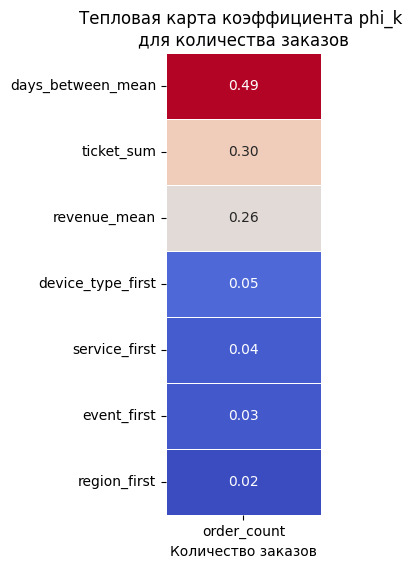

In [42]:
# Строим тепловую карту корреляции признаков профиля пользователя с числом заказов

plt.figure(figsize=(2, 6))

heatmap = correlation_matrix.loc[correlation_matrix.index != 'order_count'][['order_count']].sort_values(by = 'order_count', ascending = False)
sns.heatmap(heatmap,
            annot = True,
            fmt = '.2f', 
            cmap = 'coolwarm', 
            linewidths = 0.5, 
            cbar = False
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \nдля количества заказов')
plt.xlabel('Количество заказов')
plt.yticks(rotation = 0) # Поворачиваем подписи для тепловой карты горизонтально

plt.show()

In [43]:
# На вский случай проверим разброс данных в total_orders

df_phik.describe(include = 'all')

,device_type_first,region_first,service_first,event_first,order_count,revenue_mean,ticket_sum,days_between_mean
count,20747,20747,20747,20747,20747.000000,20747.000000,20747.000000,12413.000000
unique,2,81,34,7,NaN,NaN,NaN,NaN
top,mobile,Каменевский регион,Билеты без проблем,концерты,NaN,NaN,NaN,NaN
freq,17208,6781,4958,9191,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,4.049164,547.303384,2.744537,17.069057
std,NaN,NaN,NaN,NaN,5.113877,440.926666,0.934517,22.899074
min,NaN,NaN,NaN,NaN,1.000000,0.000000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,1.000000,203.355833,2.000000,1.000000
50%,NaN,NaN,NaN,NaN,2.000000,458.660000,2.750000,9.466667
75%,NaN,NaN,NaN,NaN,5.000000,781.243000,3.153846,22.166667


Стоит отметить, что коэффициент phi_k не показывает направление корреляции, а только её силу. Не прибегая к сегментации по пользователям и вспоминая выводы из прошлых задач, можно сказать, что:
- Количество заказов конкретного пользователя (это показатель, тесно связанный с возвратом пользователей на платформу) не зависит от региона, типа первого посещённого события, билетного оператора и типа устройства, с которого была совершена покупка.
- Вспоминая анализ средней суммы, которую пользователи тратили на один заказ, то можно сказать, что чем меньше у пользователя заказов, тем меньше в среднем будет сумма его заказа. При изучении распределения выручки по пользователям было отмечено, что новые пользователи чаще всего приходят на Яндекс Афишу за бесплатными билетами. И хотя доля пользователей, которые интересуются дешёвыми билетами, остаётся большой среди вернувшихся пользователей, с увеличением количества заказов средняя выручка за заказ увеличивается. Поэтому есть некоторая слабая корреляция количества заказов с суммой выручки.
- Анализ доли возвращающихся пользователей по количеству билетов в заказе показал, что возвращаются чаще те, кто покупает от 2 до 5 билетов: на пару, семью или компанию друзей. Реже всего возвращаются пользователи, которые совершали массовую покупку билетов, поэтому массовых заказов не так много. Именно поэтому видно слабую корреляцию количества заказов с количеством билетов в заказе.
- Наибольшая корреляция количества заказов наблюдается со средним промежутком дней между заказами. Это абсолютно логично: чем чаще пользователь заказывает билеты, тем больше заказов насчитывается у него к концу периода.

In [44]:
# Сегментация пользователей по полю total_orders

segmented_data_orders = pd.DataFrame()
segmentation_orders = []

# Берём данные grouped_data_trim, потому что нас интересуют все клиенты, даже те, которые не вернулись

for row in grouped_data_trim[['is_two', 'is_five']].itertuples(index = False): # Построчно перебираем строчки датасета и осуществляем сегментацию
    is_two, is_five = row.is_two, row.is_five
    if (not is_two) and (not is_five):
        segmentation_orders.append('1 заказ')
    if is_two and (not is_five):
        segmentation_orders.append('2-4 заказа')
    elif is_five:
        segmentation_orders.append('5 и более заказов')

segmented_data_orders['segmentation_orders'] = segmentation_orders

In [45]:
# Передаём колонки, по которым логично смотреть корреляцию
columns = ['device_type_first', 'region_first', 'service_first', 'event_first',
           'revenue_mean', 'ticket_sum', 'days_between_mean']

# Отдельно выделяем интервальные колонки, чтобы онии не спутались с категориальными
interval_cols = ['revenue_mean', 'ticket_sum', 'days_between_mean']

# Берём из исходного датасета только отобранные для рассмотрения корреляции колонки
df_phik = grouped_data_trim[columns].copy()
df_phik['segmentation_orders'] = segmentation_orders
# Строим полную корреляционную матрицу
correlation_matrix_1 = df_phik.phik_matrix(interval_cols = interval_cols)

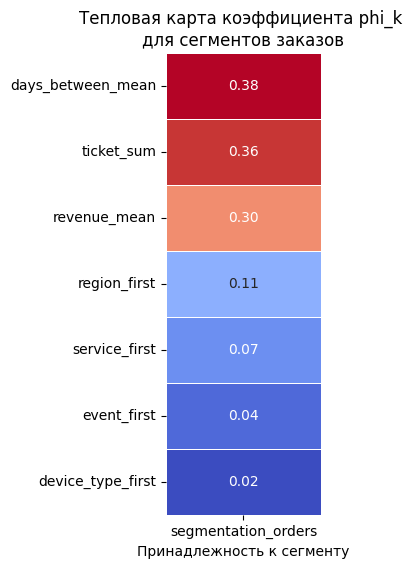

In [46]:
# Задаём размер фигуры
plt.figure(figsize=(2, 6))

heatmap = correlation_matrix_1.loc[correlation_matrix_1.index != 'segmentation_orders'][['segmentation_orders']].sort_values(by = 'segmentation_orders', ascending = False)
sns.heatmap(heatmap,
            annot = True,
            fmt = '.2f', 
            cmap = 'coolwarm', 
            linewidths = 0.5, 
            cbar = False
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \nдля сегментов заказов')
plt.xlabel('Принадлежность к сегменту')
plt.yticks(rotation = 0) # Поворачиваем подписи для тепловой карты горизонтально

plt.show()

### Краткий вывод

Тепловая карта демонстрирует степень влияния показателей профиля пользователя на нахождение пользователя в определённом сегменте по количеству заказов. В контексте сегментов, с количеством заказов больше всего связаны следующие показатели: 
- Количество дней между заказами (чем меньше — тем больше заказов),
- Количество билетов в одном заказе (чаще всего заказы на 2-5 билетов являются повторяющимися),
- Средняя выручка с заказов пользователя (чем больше заказов у пользователей, тем больше доверие к сервису и тем меньше тяготение к бесплатным билетам).

---
<a id='5'></a>
## 5. Общие выводы и рекомендации

### Данные 

Работа проводилась с данными, извлечёнными из базы данных `data-analyst-afisha`, отобранными по пользователям сервиса Яндекс Афиша за период с 1 июня по 31 октября 2024 года. Исходные данные не содержали пропусков за исключением одного столбца, пропуски в котором означали отсутствие второго заказа. В ходе подготовки данных к анализу данные были частично оптимизированы, унифицированы (значения выручки в тенге приведены к рублю с использованием информации о ежедневном изменении курса валюты) и отфильтрованы: были убраны отрицательные значения, проведена фильтрация по 99-му процентилю для исключения случаев неестественно большой выручки с продажи билетов.

### Основные выводы по анализу

После фильтрации исходной выборки и фильтрации пользователей с неестественными показателями, в выборке осталось 20747 пользователей. Из этого числа более половины пользователей оформили хотя бы 2 заказа билетов на площадке, чуть более четверти пользователей оформили 5 и более заказов, максимальное число заказов за ввременной период — 32, средняя выручка с заказа — 547 руб. Большинство заказов на билеты были оформлены пользователями в Каменевском регионе, Североярской области и Широковской области через мобильные прилржения на концерты, в театры и на категорию "другое" (стоит сегментировать эту категорию подробнее, так как это одна из самых распространённых точек входа пользователей). Самыми популярными билетными операторами стали "Билеты без проблем", "Мой билет", "Лови билет!", "Билеты в руки" и "Облачко".

Тип мероприятия, на которое был куплен первый билет, и тип устройства, с которого была совершена первая покупка, практически не влияют на вероятность возврата пользователей на платформу. Интерпретацию влияния региона или билетного оператора на возврат пользователей затрудняет существенное различие количества пользователей в каждом сегменте, хотя и отмечается, что общее количество заказов билетов в конкретном регионе имеет некоторую связь с вероятностью возврата пользователя. Первое впечатление пользователей о Яндекс Афише примерно одинаковое, несмотря на регион, тип устройства просмотра сервиса или цель покупки билета.

Пользователи, которые совершали мало заказов, в основном интересуются сервисом Яндекс Афиша с целью приобретения бесплатных билетов, очень дешёвых билетов или разового оформления больших заказов (на большую компанию или в формате корпоративных закупок). Пользователи с большим количеством заказов имеют тенденцию приобретать более дорогие билеты: средняя выручка с заказов возвращающихся пользователей стремится к 500 руб. Среднее билетов в заказе также характеризует поведение возвращающихся пользователей: чаще всего возвращаются те, кто покупают 2-5 билетов (пары, семьи и небольшие компании).

День недели совершения первого заказа влияет на общее количество заказов, но не влияет на вероятность возврата пользователя на сервис. Средний промежуток времени между заказами связан с общим количеством заказов: чем чаще пользователь совершает заказы, тем большее число заказов накапливается к концу временного периода.

Корреляционный анализ показал, что с числом заказов на платформе связаны количество дней, прошедшее между заказами (чем меньше этот период — тем больше заказов у пользователя), количество билетов в одном заказе (заказы на 2-5 билетов повторяются чаще всего) и средняя выручка с заказов пользователя (чем больше у пользователя заказов, тем больше становится средняя выручка с его покупок).

### Рекомендации

Во время анализа существенный акцент был сделан на возвращаемости пользователей, значит, основная цель сервиса — увеличить количество повторных покупок. Здесь важно сегментировать пользователей и предлагать им рекомендации в соответствии с количеством билетов, которые они обычно приобретают, и в том же ценовом диапазоне. Например:
- Для тех, кто покупает 2-5 билетов (очень высокая вероятность возврата) — подборки "для двоих", "что посмотреть всей семьёй".
- Для тех, кто покупает 1 билет (вероятность возврата меньше) — подборки похожих событий, акции "пригласи друга на фильм", "вместе — выгоднее".
- Для тех, кто покупает более 5 билетов (низкая вероятность возврата) — скидки на оптовые покупки, функции покупки билетов "покупайте как юрлицо", "при оформлении автоматически сформируем документы для компании".

Также можно делить пользователей по типу поведения:
- Пользователям, которые приходят за бесплатными/дешёвыми билетами предлагать похожее, чтобы добитсья второй покупки, после чего плавно поднимать ценовой сегмент билетов на мероприятия того же жанра. Для них нужно сделать упор на частоту покупки, чтобы завлечь их в сервис.
- С пользователями, которые сразу приходят покупать билеты среднего ценового диапазона, чаще предлагать поделиться мнением или оставить отзыв о том, что им не нравится, подчёркивая важность их комфортного использования сервиса. Так можно повысить их лояльность.

Стоит отметить, что основные точки входа на сервис — категории концертов и театров. Можно сделать для новых пользователей удобные витрины с билетами именно этих категорий, а потом по первым заказам настраивать более персонализированные рекомендации, которые смогут поднять популярность и других категорий. Очень важно декомпозировать категорию "другое" на большее количество категорий.

Осталось не совсем понятным, как взаимодействуют с платформой билетные операторы. Возможно, есть шанс увеличить возврат пользователей через предоставление скидок на билеты от определённых операторов.

### Ссылка на удалённый репозиторий, в котором размещён проект: